In [1]:
# Force-downgrade to the v4.x ecosystem where TensorFlow/Keras classes exist natively
!pip install "transformers<5.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.16.1
    Uninstalling huggingface_hub-1.16.1:
      Successfully uninstalled huggingface_hub-1.16.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [1]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Set the dataset directory path
DATASET_DIR = '/content/drive/MyDrive/COVID_19_dataset'

print("Verifying directory paths...")
print("Train path exists:", os.path.exists(os.path.join(DATASET_DIR, 'train')))
print("Val path exists:", os.path.exists(os.path.join(DATASET_DIR, 'val')))
print("Test path exists:", os.path.exists(os.path.join(DATASET_DIR, 'test')))

Mounted at /content/drive
Verifying directory paths...
Train path exists: True
Val path exists: True
Test path exists: True


In [2]:
import tensorflow as tf
from tensorflow.keras import layers

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

print("Loading Training Dataset...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, 'train'),
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

print("\nLoading Validation Dataset...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, 'val'),
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

print("\nLoading Test Dataset...")
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, 'test'),
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_ds.class_names
print("\nDetected Classes:", class_names)

Loading Training Dataset...
Found 3011 files belonging to 3 classes.

Loading Validation Dataset...
Found 600 files belonging to 3 classes.

Loading Test Dataset...
Found 435 files belonging to 3 classes.

Detected Classes: ['COVID', 'Normal', 'Viral Pneumonia']


In [3]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)
print("Data performance pipelines configured successfully.")

Data performance pipelines configured successfully.


In [4]:
from tensorflow.keras import layers, models
from tensorflow.keras.metrics import Precision, Recall

# 1. Load the pre-trained DenseNet121 base model
base_model = tf.keras.applications.DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the backbone weights
base_model.trainable = False

# 2. Construct the network architecture
inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.densenet.preprocess_input(inputs)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(3, activation='softmax', name="predictions")(x)

model = models.Model(inputs, outputs)

# 3. Compile with required assignment metrics
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │         3,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,040,579 (26.86 MB)

 Trainable params: 3,075 (12.01 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint_path = os.path.join(DATASET_DIR, 'best_densenet_model.keras')

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
]

EPOCHS = 15
print("Starting Model Training Baseline...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)

Starting Model Training Baseline...
Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5936 - loss: 0.8844 - precision: 0.6246 - recall: 0.5239
Epoch 1: val_loss improved from None to 0.39289, saving model to /content/drive/MyDrive/COVID_19_dataset/best_densenet_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/COVID_19_dataset/best_densenet_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 608s 6s/step - accuracy: 0.6908 - loss: 0.6898 - precision: 0.7237 - recall: 0.6410 - val_accuracy: 0.8450 - val_loss: 0.3929 - val_precision: 0.8505 - val_recall: 0.8250
Epoch 2/15
94/95 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7935 - loss: 0.4859 - precision: 0.8021 - recall: 0.7749
Epoch 2: val_loss improved from 0.39289 to 0.32980, saving model to /content/drive/MyDrive/COVID_19_dataset/best_densenet_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/COVID_19_dataset/best_densenet_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.8

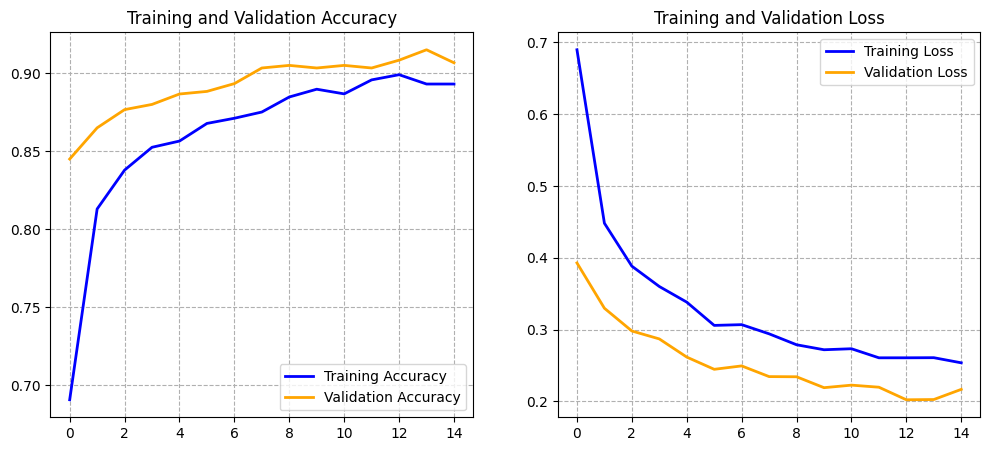


Evaluating Model performance on unseen Test Set...
14/14 ━━━━━━━━━━━━━━━━━━━━ 80s 6s/step - accuracy: 0.9356 - loss: 0.1849 - precision: 0.9356 - recall: 0.9356
Test Loss: 0.1849
Test Compile_metrics: 0.9356


In [6]:
import matplotlib.pyplot as plt

# Plotting curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--')
plt.show()

# Evaluate Test Dataset
print("\nEvaluating Model performance on unseen Test Set...")
test_results = model.evaluate(test_ds, verbose=1)
for metric_name, val in zip(model.metrics_names, test_results):
    print(f"Test {metric_name.capitalize()}: {val:.4f}")

In [7]:
import cv2
import numpy as np

def generate_gradcam_heatmap(model, img_array, base_model_layer_name='densenet121', pred_index=None):
    base_block = model.get_layer(base_model_layer_name)
    target_layer = base_block.get_layer('relu')

    inner_grad_model = tf.keras.models.Model(
        inputs=[base_block.inputs],
        outputs=[target_layer.output, base_block.output]
    )

    processed_img = tf.keras.applications.densenet.preprocess_input(img_array)

    with tf.GradientTape() as tape:
        conv_outputs, base_features = inner_grad_model(processed_img)
        x = model.get_layer('global_average_pooling2d')(base_features)
        x = model.get_layer('dropout')(x)
        preds = model.get_layer('predictions')(x)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


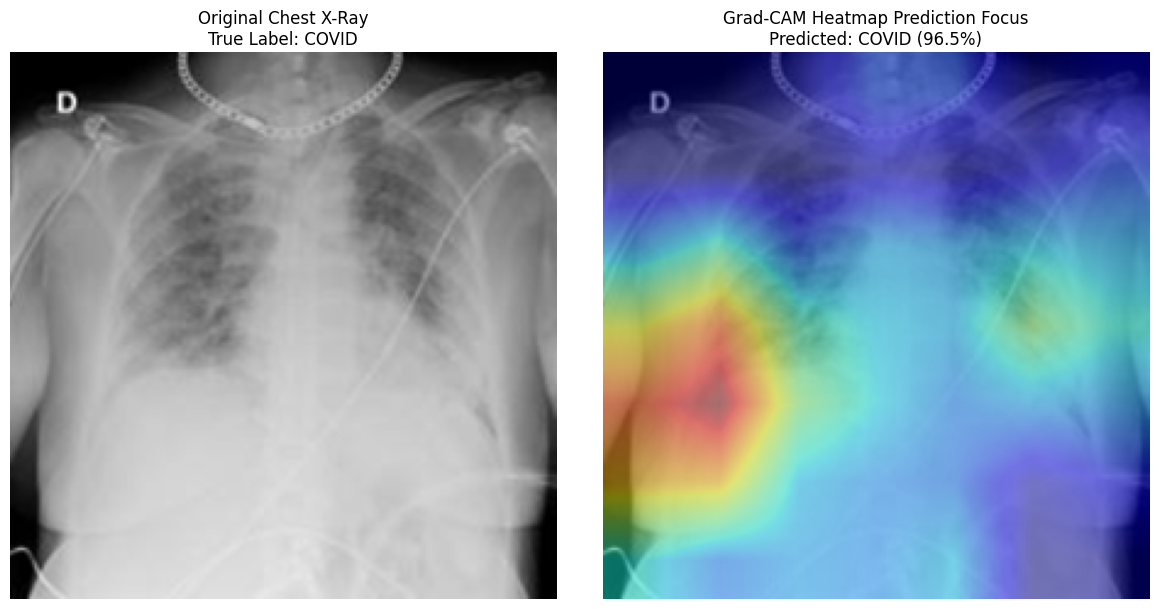

In [12]:
# Extract sample image from test pipeline iterator
images, labels = next(iter(test_ds.take(1)))
sample_img = tf.expand_dims(images[0], axis=0)
true_class_name = class_names[np.argmax(labels[0])]

# Make inference prediction
predictions = model.predict(sample_img)
predicted_label_idx = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_label_idx]

# Run Grad-CAM
heatmap = generate_gradcam_heatmap(model, sample_img, 'densenet121', predicted_label_idx)

# Display Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
display_img = (images[0].numpy() - images[0].numpy().min()) / (images[0].numpy().max() - images[0].numpy().min())

axes[0].imshow(display_img)
axes[0].set_title(f"Original Chest X-Ray\nTrue Label: {true_class_name.upper()}")
axes[0].axis('off')

axes[1].imshow(display_img)
axes[1].imshow(cv2.resize(heatmap, (224, 224)), cmap='jet', alpha=0.45)
axes[1].set_title(f"Grad-CAM Heatmap Prediction Focus\nPredicted: {predicted_class_name.upper()} ({predictions[0][predicted_label_idx]*100:.1f}%)")
axes[1].axis('off')
plt.tight_layout()
plt.show()

--- Saliency Map Metrics ---
Shannon Entropy Score: 5.1025 bits



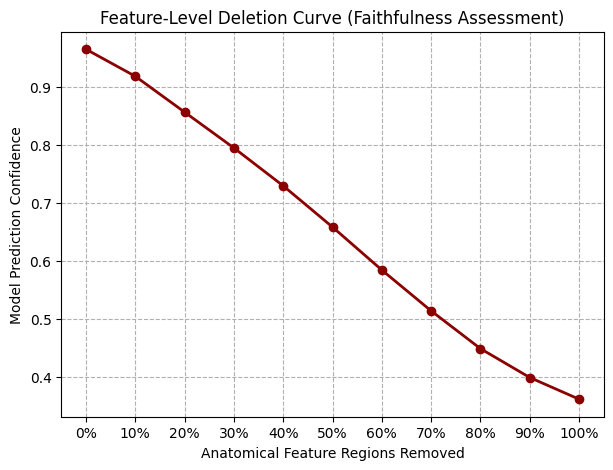

In [13]:
def calculate_heatmap_entropy(heatmap):
    flat_map = heatmap.flatten()
    flat_map = flat_map / (np.sum(flat_map) + 1e-8)
    probs = flat_map[flat_map > 0]
    return -np.sum(probs * np.log2(probs))

def run_feature_level_deletion(model, img_tensor, base_model_name='densenet121', steps=10):
    base_block = model.get_layer(base_model_name)
    target_layer = base_block.get_layer('relu')

    feature_model = tf.keras.models.Model(inputs=[base_block.inputs], outputs=[target_layer.output])
    processed_img = tf.keras.applications.densenet.preprocess_input(img_tensor)
    original_feature_maps = feature_model(processed_img)

    with tf.GradientTape() as tape:
        conv_outputs = feature_model(processed_img)
        x = model.get_layer('global_average_pooling2d')(conv_outputs)
        x = model.get_layer('dropout')(x)
        preds = model.get_layer('predictions')(x)
        target_class = tf.argmax(preds[0])
        class_score = preds[:, target_class]

    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap_7x7 = tf.reduce_mean(conv_outputs[0] * pooled_grads, axis=-1).numpy()
    heatmap_7x7 = np.maximum(heatmap_7x7, 0)
    sorted_grid_indices = np.argsort(heatmap_7x7.flatten())[::-1]

    confidences = [class_score.numpy()[0]]
    modified_features = original_feature_maps.numpy()
    cells_per_step = len(sorted_grid_indices) // steps

    for step in range(steps):
        start_idx = step * cells_per_step
        end_idx = min((step + 1) * cells_per_step, len(sorted_grid_indices))
        for idx in range(start_idx, end_idx):
            grid_pos = sorted_grid_indices[idx]
            y, x_coord = np.unravel_index(grid_pos, (7, 7))
            modified_features[0, y, x_coord, :] = 0.0

        feat_input = tf.convert_to_tensor(modified_features)
        x_head = model.get_layer('global_average_pooling2d')(feat_input)
        x_head = model.get_layer('dropout')(x_head)
        new_preds = model.get_layer('predictions')(x_head)
        confidences.append(new_preds[0][target_class].numpy())

    return confidences

# Run & Display
entropy_score = calculate_heatmap_entropy(heatmap)
print(f"--- Saliency Map Metrics ---")
print(f"Shannon Entropy Score: {entropy_score:.4f} bits\n")

steps_count = 10
confidence_drop_curve = run_feature_level_deletion(model, sample_img, 'densenet121', steps=steps_count)

plt.figure(figsize=(7, 5))
plt.plot(range(steps_count + 1), confidence_drop_curve, marker='o', color='darkred', linewidth=2)
plt.title('Feature-Level Deletion Curve (Faithfulness Assessment)')
plt.xlabel('Anatomical Feature Regions Removed')
plt.ylabel('Model Prediction Confidence')
plt.grid(True, linestyle='--')
plt.xticks(range(steps_count + 1), labels=[f"{i*10}%" for i in range(steps_count + 1)])
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)



Final Dataset AOPC Score: 0.2579


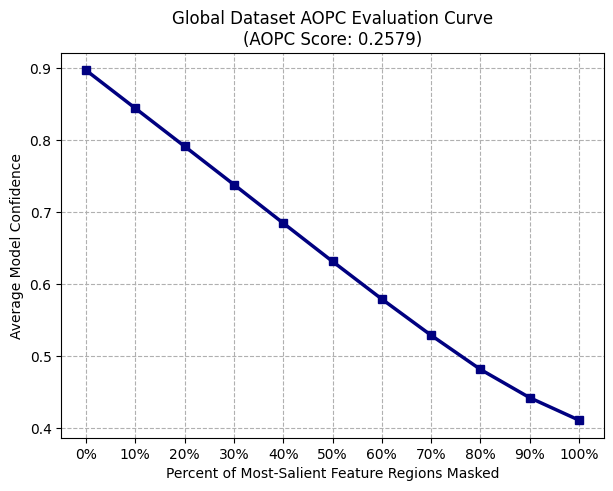

In [14]:
def calculate_dataset_aopc(model, dataset, base_model_name='densenet121', steps=10, num_samples=50):
    base_block = model.get_layer(base_model_name)
    target_layer = base_block.get_layer('relu')
    feature_model = tf.keras.models.Model(inputs=[base_block.inputs], outputs=[target_layer.output])

    all_curves = []
    samples_processed = 0

    for images, labels in dataset:
        if samples_processed >= num_samples: break
        for i in range(len(images)):
            if samples_processed >= num_samples: break

            img_tensor = tf.expand_dims(images[i], axis=0)
            processed_img = tf.keras.applications.densenet.preprocess_input(img_tensor)
            conv_outputs = feature_model(processed_img)

            with tf.GradientTape() as tape:
                tape.watch(conv_outputs)
                c_outputs = feature_model(processed_img)
                x_head = model.get_layer('global_average_pooling2d')(c_outputs)
                x_head = model.get_layer('dropout')(x_head)
                p_outputs = model.get_layer('predictions')(x_head)
                target_class = tf.argmax(p_outputs[0])
                class_score = p_outputs[:, target_class]

            grads = tape.gradient(class_score, c_outputs)
            pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

            heatmap_7x7 = tf.reduce_mean(conv_outputs[0] * pooled_grads, axis=-1).numpy()
            heatmap_7x7 = np.maximum(heatmap_7x7, 0)
            sorted_grid_indices = np.argsort(heatmap_7x7.flatten())[::-1]

            confidences = [class_score.numpy()[0]]
            modified_features = conv_outputs.numpy()
            cells_per_step = len(sorted_grid_indices) // steps

            for step in range(steps):
                start_idx = step * cells_per_step
                end_idx = min((step + 1) * cells_per_step, len(sorted_grid_indices))
                for idx in range(start_idx, end_idx):
                    grid_pos = sorted_grid_indices[idx]
                    y, x_coord = np.unravel_index(grid_pos, (7, 7))
                    modified_features[0, y, x_coord, :] = 0.0

                feat_input = tf.convert_to_tensor(modified_features)
                x_h = model.get_layer('global_average_pooling2d')(feat_input)
                x_h = model.get_layer('dropout')(x_h)
                new_preds = model.get_layer('predictions')(x_h)
                confidences.append(new_preds[0][target_class].numpy())

            all_curves.append(confidences)
            samples_processed += 1

    mean_curve = np.mean(all_curves, axis=0)
    base_confidence = mean_curve[0]
    aopc_score = np.sum([base_confidence - p for p in mean_curve[1:]]) / (steps + 1)
    return mean_curve, aopc_score

# Compute and Plot
steps_total = 10
mean_steps_curve, final_aopc = calculate_dataset_aopc(model, test_ds, 'densenet121', steps=steps_total, num_samples=50)

print(f"\n=====================================")
print(f"Final Dataset AOPC Score: {final_aopc:.4f}")
print(f"=====================================")

plt.figure(figsize=(7, 5))
plt.plot(range(steps_total + 1), mean_steps_curve, marker='s', color='navy', linewidth=2.5)
plt.title(f'Global Dataset AOPC Evaluation Curve\n(AOPC Score: {final_aopc:.4f})')
plt.xlabel('Percent of Most-Salient Feature Regions Masked')
plt.ylabel('Average Model Confidence')
plt.grid(True, linestyle='--')
plt.xticks(range(steps_total + 1), labels=[f"{i*10}%" for i in range(steps_total + 1)])
plt.show()

In [19]:
import tensorflow as tf
from transformers import TFAutoModel

print("Loading raw pre-trained Vision Transformer backbone container...")
# 1. Load the clean backbone feature extraction engine directly
vit_backbone = TFAutoModel.from_pretrained(
    'google/vit-base-patch16-224',
    from_pt=True
)

# Freeze the transformer encoder backbone completely
vit_backbone.vit.trainable = False

# 2. Define an explicit Keras Layer to encapsulate the Transformer Backbone safely
class ViTBackboneLayer(tf.keras.layers.Layer):
    def __init__(self, vit_model, **kwargs):
        super(ViTBackboneLayer, self).__init__(**kwargs)
        self.vit = vit_model

    def call(self, inputs):
        # Unwrap the Keras symbolic tensor to raw TensorFlow tensor implicitly
        outputs = self.vit(pixel_values=inputs)
        return outputs.pooler_output

    def compute_output_shape(self, input_shape):
        # Explicitly tell Keras 3 that the output will always have 768 features
        # This completely resolves the NotImplementedError shape tracking crash
        return (input_shape[0], 768)

# 3. Construct the functional Keras network graph
inputs = tf.keras.Input(shape=(224, 224, 3))

# Normalize inputs to match transformer expectations [-1, 1]
x = tf.keras.layers.Rescaling(1.0 / 127.5, offset=-1.0)(inputs)

# Transpose image channels to match transformer sequence layout: (Batch, Channels, Height, Width)
x = tf.keras.layers.Permute((3, 1, 2))(x)

# Pass through our customized shape-retaining wrapper layer
cls_token_representation = ViTBackboneLayer(vit_backbone)(x)

# Regularization to prevent overfitting
x = tf.keras.layers.Dropout(0.3)(cls_token_representation)

# Your explicit 3-class assignment target output layer with Softmax activation
outputs = tf.keras.layers.Dense(3, activation='softmax', name="predictions")(x)

# Instantiate the full custom model pipeline wrapper
vit_model = tf.keras.models.Model(inputs=inputs, outputs=outputs)

# Compile using your standard metrics setup
vit_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

vit_model.summary()

Loading raw pre-trained Vision Transformer backbone container...


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFViTModel: ['classifier.weight', 'classifier.bias']
- This IS expected if you are initializing TFViTModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFViTModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFViTModel were not initialized from the PyTorch model and are newly initialized: ['vit.pooler.dense.weight', 'vit.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_2 (Permute)             │ (None, 3, 224, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone_layer             │ (None, 768)            │             0 │
│ (ViTBackboneLayer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │         2,307 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,307 (9.01 KB)

 Trainable params: 2,307 (9.01 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

vit_checkpoint_path = os.path.join(DATASET_DIR, 'best_vit_model.weights.h5') # Changed extension to .weights.h5

vit_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=vit_checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True, # CRITICAL FIX: Avoids calling get_config() entirely
        verbose=1
    )
]

print("Starting Vision Transformer Training Pipeline (Weights-Only Checkpoint)...")
vit_history = vit_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=vit_callbacks,
    verbose=1
)

Starting Vision Transformer Training Pipeline (Weights-Only Checkpoint)...
Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.7204 - loss: 0.7231 - precision: 0.7892 - recall: 0.5621
Epoch 1: val_loss improved from None to 0.59979, saving model to /content/drive/MyDrive/COVID_19_dataset/best_vit_model.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/COVID_19_dataset/best_vit_model.weights.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 45s 472ms/step - accuracy: 0.7466 - loss: 0.6764 - precision: 0.8129 - recall: 0.6074 - val_accuracy: 0.8117 - val_loss: 0.5998 - val_precision: 0.8525 - val_recall: 0.6933
Epoch 2/10
94/95 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.7625 - loss: 0.6206 - precision: 0.8062 - recall: 0.6698
Epoch 2: val_loss improved from 0.59979 to 0.53427, saving model to /content/drive/MyDrive/COVID_19_dataset/best_vit_model.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/COVID_19_dataset/best_vit_model.weights.h5
95/95 ━━━━━━

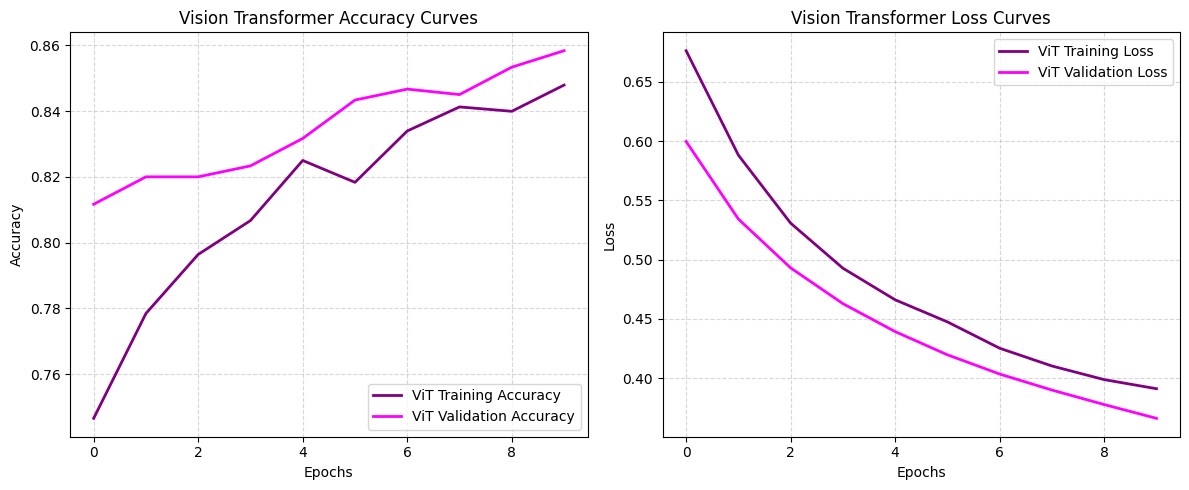


Evaluating Vision Transformer performance on unseen Test Set...
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 635ms/step - accuracy: 0.8690 - loss: 0.3346 - precision: 0.8821 - recall: 0.8598

       ViT Final Test Results        
ViT Test Loss: 0.3346
ViT Test Compile_metrics: 0.8690


In [22]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Plot Accuracy & Loss Curves side-by-side
vit_acc = vit_history.history['accuracy']
vit_val_acc = vit_history.history['val_accuracy']
vit_loss = vit_history.history['loss']
vit_val_loss = vit_history.history['val_loss']
epochs_range = range(len(vit_acc))

plt.figure(figsize=(12, 5))

# Subplot 1: Accuracy Evolution
plt.subplot(1, 2, 1)
plt.plot(epochs_range, vit_acc, label='ViT Training Accuracy', color='purple', linewidth=2)
plt.plot(epochs_range, vit_val_acc, label='ViT Validation Accuracy', color='magenta', linewidth=2)
plt.title('Vision Transformer Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Loss Evolution
plt.subplot(1, 2, 2)
plt.plot(epochs_range, vit_loss, label='ViT Training Loss', color='purple', linewidth=2)
plt.plot(epochs_range, vit_val_loss, label='ViT Validation Loss', color='magenta', linewidth=2)
plt.title('Vision Transformer Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 2. Evaluate the Model on Unseen Test Data
print("\nEvaluating Vision Transformer performance on unseen Test Set...")
vit_test_results = vit_model.evaluate(test_ds, verbose=1)

# Display final compiled metrics neatly mapped to names
print(f"\n=====================================")
print(f"       ViT Final Test Results        ")
print(f"=====================================")
for metric_name, val in zip(vit_model.metrics_names, vit_test_results):
    print(f"ViT Test {metric_name.capitalize()}: {val:.4f}")
print(f"=====================================")